# ACWR Prediction Pipeline — Real Madrid Internship
**Group A | 2024–25 Season**

This notebook covers the full data pipeline for the **Acute vs Chronic Workload Ratio (ACWR)** project: raw data ingestion, cleaning, daily aggregation, full-calendar grid construction, and EWMA-based ACWR computation for all 29 squad players across three external load metrics.

**Load metrics used:**
- `total_distance` — aerobic volume (m)
- `acc_band7plus_total_effort_count` — high-intensity accelerations (count)
- `velocity_band6plus7_total_distance` — high-speed running (m)

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
df = pd.read_csv("data_acute_vs_chronic.csv")

In [83]:
df.head()

,player_id,period_id,period_name,activity_id,period_start_time,position_name_en,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth
0,37191,period_1683,BP 2351,activity_1389,2024-12-16T00:00:00Z,Central Back,NaN,1003.372036,0,0.000000,184.0,79.0,1997-06-22
1,37191,period_4407,G 1669,activity_2423,2025-01-01T00:00:00Z,Central Back,NaN,1223.749101,4,4.960388,184.0,79.0,1997-06-22
2,37191,period_883,BP 4893,activity_4655,2025-04-06T00:00:00Z,Central Back,NaN,747.250469,4,0.000000,184.0,79.0,1997-06-22
3,37191,period_1790,G 3164,activity_911,2025-04-03T00:00:00Z,Central Back,NaN,1196.351675,2,0.000000,184.0,79.0,1997-06-22
4,37191,period_2421,BP 0518,activity_3073,2025-05-06T00:00:00Z,Central Back,NaN,322.200458,2,0.000000,184.0,79.0,1997-06-22


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3903 entries, 0 to 3902
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   player_id                           3903 non-null   int64  
 1   period_id                           3903 non-null   object 
 2   period_name                         2930 non-null   object 
 3   activity_id                         3903 non-null   object 
 4   period_start_time                   3903 non-null   object 
 5   position_name_en                    3884 non-null   object 
 6   is_official_match                   973 non-null    float64
 7   total_distance                      3903 non-null   float64
 8   acc_band7plus_total_effort_count    3903 non-null   int64  
 9   velocity_band6plus7_total_distance  3903 non-null   float64
 10  height                              3884 non-null   float64
 11  weight                              3884 no

# 1. Data Cleaning & Feature Engineering

The raw dataset contains one row per training *period* (drill/block within a session). We apply type corrections, parse structured fields, and resolve anomalies before aggregating to daily load.

## 1.1 Fix `is_official_match` and `player_id` types

`is_official_match` is `NaN` for all 2,930 training rows and `1.0` for all 973 match rows — the pattern is unambiguous, so we fill `NaN → False` and cast to boolean. `player_id` is cast to `category` for efficient groupby operations.

In [85]:
df['is_official_match'] = df['is_official_match'].fillna(0).astype(bool)

# Changing datatype of player_id to object
df['player_id'] = df['player_id'].astype('category')

## 1.2 Parse `exercise_type` from `period_name`

`period_name` encodes drill IDs as `{CATEGORY} {DRILL_ID}` (e.g., `G 1960`, `TAC 0133`). The prefix is the meaningful training category. Match rows always have `NaN` in `period_name`, perfectly correlated with `is_official_match == True`.

In [86]:
df['period_name'].str.split(' ').str[0].value_counts()

period_name
G      1184
TAC     800
BP      684
TEC     262
Name: count, dtype: int64

Training categories decoded from the `period_name` prefix:

| Prefix | Category | Count |
|--------|----------|-------|
| `G` | Game-based / small-sided games | 1,184 |
| `TAC` | Tactical | 800 |
| `BP` | *Balón parado* / set pieces | 684 |
| `TEC` | Technical | 262 |
| `NaN` | Official match (no drill logged) | 973 |

All 973 `NaN` entries are match rows — no training periods have a missing `period_name`.

In [87]:
print("Missing values in period_name when is_official_match is True",df[df['is_official_match']==True].period_name.isna().sum())

print("Missing values in period_name when is_official_match is False",df[df['is_official_match']==False].period_name.isna().sum())

Missing values in period_name when is_official_match is True 973
Missing values in period_name when is_official_match is False 0


All `NaN` entries in `period_name` correspond exactly to official matches. We label them `"MATCH"` and extract the prefix as a new `exercise_type` column. Individual drill IDs are too granular to model at our dataset scale.

In [88]:
df['period_name'] = df['period_name'].fillna("MATCH")

df['exercise_type'] = df['period_name'].str.split(' ').str[0]

## 1.3 Parse datetime columns and extract session date

`period_start_time` and `date_of_birth` are stored as ISO 8601 strings. The time component of `period_start_time` is always `00:00:00`, so we extract only the calendar date and drop the original column to avoid redundancy.

In [89]:
df['period_start_time'] = pd.to_datetime(df['period_start_time'])
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
df['date'] = pd.to_datetime(df['period_start_time'].dt.date)
df = df.drop(columns=['period_start_time'])

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3903 entries, 0 to 3902
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   player_id                           3903 non-null   category      
 1   period_id                           3903 non-null   object        
 2   period_name                         3903 non-null   object        
 3   activity_id                         3903 non-null   object        
 4   position_name_en                    3884 non-null   object        
 5   is_official_match                   3903 non-null   bool          
 6   total_distance                      3903 non-null   float64       
 7   acc_band7plus_total_effort_count    3903 non-null   int64         
 8   velocity_band6plus7_total_distance  3903 non-null   float64       
 9   height                              3884 non-null   float64       
 10  weight                  

## 1.4 Compute player age at session date

Age is computed as a float (days / 365.25) at each row's specific date, not at a fixed reference date. This ensures the model always receives the player's correct age when predicting load for a future session.

In [91]:
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
df['age'] = ((df['date'] - df['date_of_birth']).dt.days / 365.25).round(0)

print(f"Age range: {df['age'].min():.0f} - {df['age'].max():.0f}")
print(f"Age nulls: {df['age'].isna().sum()}")

Age range: 17 - 56
Age nulls: 19


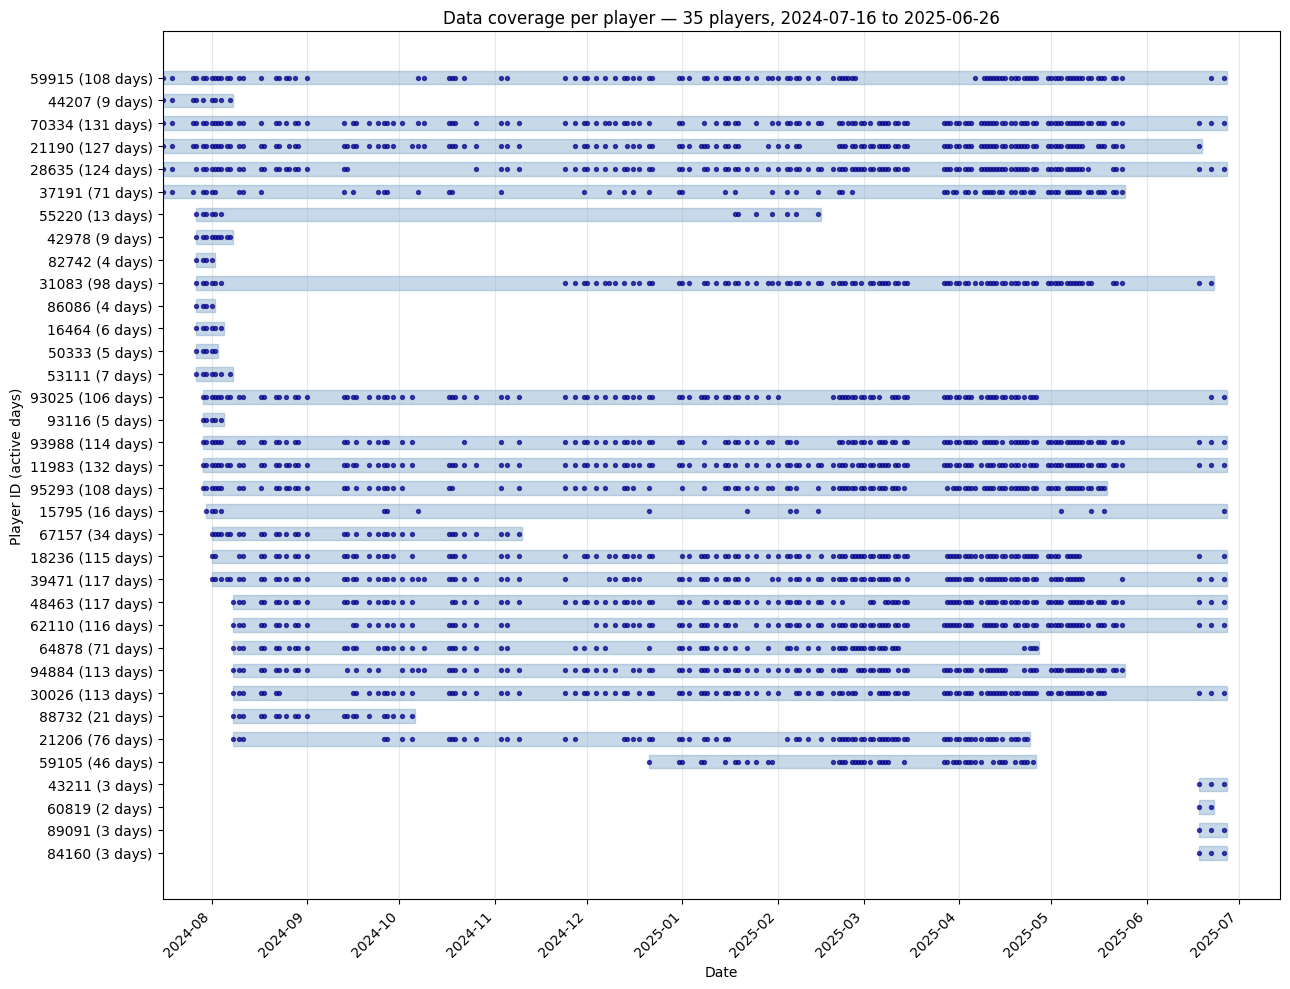

   player_id first_date  last_date  n_days  n_rows
0      59915 2024-07-16 2025-06-26     108     204
1      44207 2024-07-16 2024-08-07       9      24
2      70334 2024-07-16 2025-06-26     131     245
3      21190 2024-07-16 2025-06-18     127     237
4      28635 2024-07-16 2025-06-26     124     223
5      37191 2024-07-16 2025-05-24      71     168
6      55220 2024-07-27 2025-02-14      13      30
7      42978 2024-07-27 2024-08-07       9      21
8      82742 2024-07-27 2024-08-01       4      12
9      31083 2024-07-27 2025-06-22      98     174
10     86086 2024-07-27 2024-08-01       4      10
11     16464 2024-07-27 2024-08-04       6      20
12     50333 2024-07-27 2024-08-02       5      19
13     53111 2024-07-27 2024-08-07       7      17
14     93025 2024-07-29 2025-06-26     106     177
15     93116 2024-07-29 2024-08-04       5      16
16     93988 2024-07-29 2025-06-26     114     221
17     11983 2024-07-29 2025-06-26     132     232
18     95293 2024-07-29 2025-05

In [92]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_player_date_ranges(df, date_col='date', player_col='player_id',
                             figsize=(13, 10), show_activity=True):
    """
    Gantt-style plot of each player's date range.
    
    Parameters
    ----------
    df : pd.DataFrame
        Row-level or daily-level dataframe.
    date_col : str
        Column containing the date/datetime values.
    player_col : str
        Column identifying the player.
    figsize : tuple
        Figure size.
    show_activity : bool
        If True, also plot individual activity days as dots on top of the range bar.
    """
    # Ensure date column is datetime
    dates = pd.to_datetime(df[date_col])
    
    # Get first and last date per player, and sort by first date so the chart reads nicely
    summary = df.assign(_date=dates).groupby(player_col, observed=True).agg(
        first_date=('_date', 'min'),
        last_date=('_date', 'max'),
        n_days=('_date', 'nunique'),
        n_rows=('_date', 'count'),
    ).sort_values('first_date').reset_index()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # One horizontal bar per player showing their activity window
    for i, row in summary.iterrows():
        ax.barh(y=i, 
                width=(row['last_date'] - row['first_date']).days + 1,
                left=row['first_date'],
                height=0.6,
                color='steelblue', alpha=0.3, edgecolor='steelblue')
        
        # Overlay individual activity dates as dots
        if show_activity:
            player_dates = dates[df[player_col] == row[player_col]].unique()
            ax.scatter(player_dates, [i] * len(player_dates),
                       s=8, color='darkblue', alpha=0.7, zorder=3)
    
    # Y-axis: player IDs, ordered by first appearance
    ax.set_yticks(range(len(summary)))
    ax.set_yticklabels([f"{pid} ({n} days)" for pid, n in 
                        zip(summary[player_col], summary['n_days'])])
    ax.set_xlabel('Date')
    ax.set_ylabel('Player ID (active days)')
    ax.set_title(f'Data coverage per player — {len(summary)} players, '
                 f'{dates.min().date()} to {dates.max().date()}')
    
    # Format x-axis with monthly ticks
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    ax.grid(True, axis='x', alpha=0.3)
    ax.invert_yaxis()  # first-appearing player at top
    
    plt.tight_layout()
    plt.show()
    
    return summary


# Run it on your cleaned row-level dataframe (after exclusions)
summary = plot_player_date_ranges(df)
print(summary)

## 1.5 Exclude players with missing metadata

One player (ID 50333) appears only during the first week of preseason with no anthropometric or positional metadata whatsoever. Without height, weight, position, or date of birth, this player cannot be featurised and is excluded via a `dropna` on those columns.

In [93]:
# Before dropping, document what you're removing and why
affected = df[df['height'].isna()]
print(f"Dropping {len(affected)} rows ({len(affected)/len(df):.2%}) "
      f"from {affected['player_id'].nunique()} player(s) with no metadata")

df = df.dropna(subset=['height', 'weight', 'position_name_en', 'date_of_birth']).reset_index(drop=True)

assert df.isna().sum().sum() == 0 or df.isna().sum()[df.isna().sum() > 0].index.tolist() == []
# or more explicit:
assert df[['player_id', 'height', 'weight', 'position_name_en', 'date_of_birth']].isna().sum().sum() == 0

Dropping 19 rows (0.49%) from 1 player(s) with no metadata


# 2. Outlier Detection and Treatment

We inspect the numeric column distributions and investigate extreme values before finalising the clean dataset.

In [94]:
df.describe()

,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth,date,age
count,3884.000000,3884.000000,3884.000000,3884.000000,3884.000000,3884,3884,3884.000000
mean,1335.787003,4.980690,13.381160,176.972451,75.903193,1998-08-06 12:03:20.205973248,2025-01-11 01:36:23.728115456,26.418126
min,44.093973,0.000000,0.000000,169.000000,64.000000,1969-01-16 00:00:00,2024-07-16 00:00:00,17.000000
25%,713.652944,2.000000,0.000000,173.000000,67.000000,1996-07-28 00:00:00,2024-09-28 12:00:00,23.000000
50%,1170.381759,5.000000,1.300446,177.000000,71.000000,1999-03-09 00:00:00,2025-02-07 00:00:00,26.000000
75%,1676.451363,7.000000,20.953205,181.000000,79.000000,2002-03-24 00:00:00,2025-04-12 00:00:00,29.000000
max,32299.892493,27.000000,191.200596,195.000000,200.000000,2007-09-02 00:00:00,2025-06-26 00:00:00,56.000000
std,1043.734660,3.772078,20.737091,5.486529,19.355849,NaN,NaN,5.867605


Three anomalies are visible in `describe()`:

- **`total_distance = 32,299 m`** — physiologically impossible for a single period (professional matches are ~10–12 km total).
- **`weight = 200`** — implausible; matches a known placeholder seen in suspect player records.
- **`date_of_birth` min = 1969 / `age` max = 56** — no active first-team player is 56 years old.

We address each anomaly below.

## 2.1 Anomalous `total_distance` — player 94884, 2025-02-15

Only `total_distance` is anomalous for this single MATCH row; the acceleration and HSR values (`acc = 15`, `hsr = 23.5 m`) are within normal match ranges. This points to a GPS export/parsing error on a single field, not a sensor malfunction.

In [95]:
df.sort_values(by='total_distance', ascending=False).head()

,player_id,period_id,period_name,activity_id,position_name_en,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth,exercise_type,date,age
3765,94884,period_1501,MATCH,activity_3585,Forward,True,32299.892493,15,23.465222,175.0,78.0,1998-07-14,MATCH,2025-02-15,27.0
2152,11983,period_3493,MATCH,activity_1612,Central Midfielder,True,11093.472232,4,2.068091,172.0,66.0,1985-11-07,MATCH,2024-12-10,39.0
1328,21190,period_2160,MATCH,activity_26,Full Back,True,8163.381856,11,47.841802,173.0,71.0,1991-03-18,MATCH,2025-04-13,34.0
2903,93988,period_934,TAC 2764,activity_3073,Central Midfielder,False,7986.864611,2,54.079530,170.0,70.0,2005-05-31,TAC,2025-05-06,20.0
1884,48463,period_4655,MATCH,activity_1778,Central Midfielder,True,7831.834147,3,56.349076,181.0,77.0,1998-03-22,MATCH,2024-09-21,27.0


The anomaly is isolated to one row for player 94884 (Forward). We subset this player's official match records to inspect the full distance distribution.

In [96]:
df_94884 = df[(df['player_id']==94884) & (df['is_official_match']==True)]

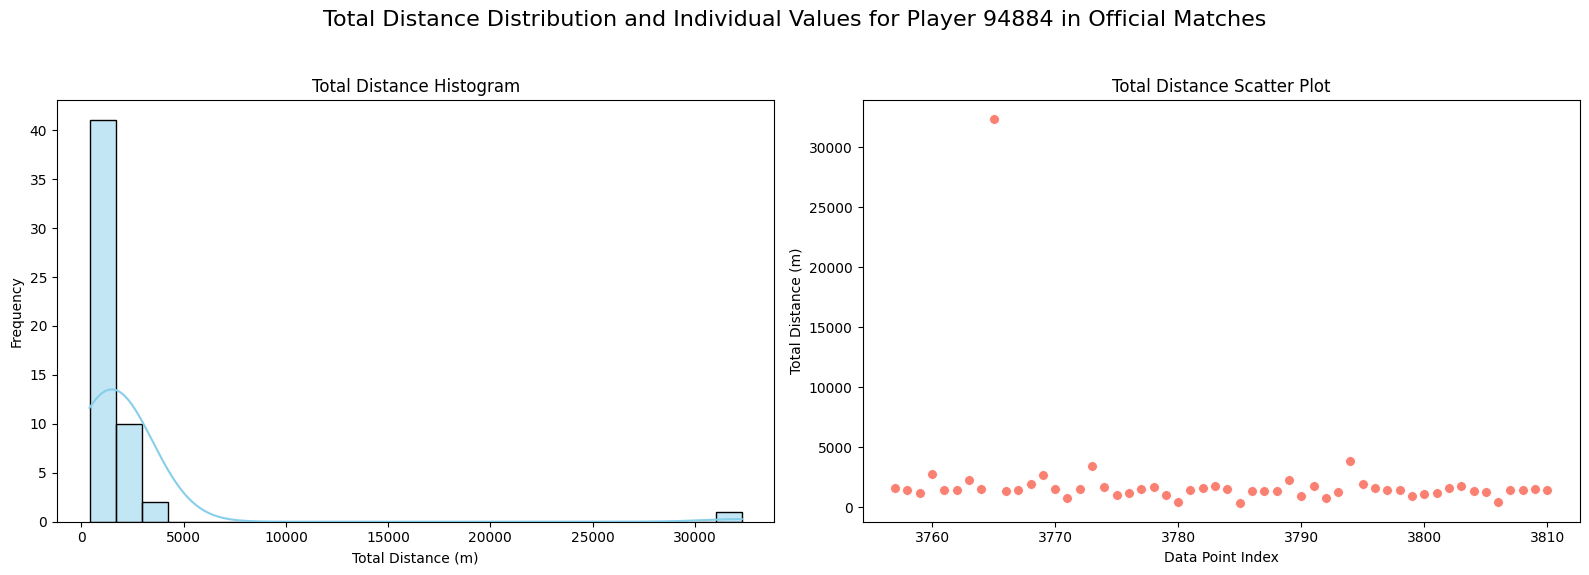

In [97]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Total Distance Distribution and Individual Values for Player 94884 in Official Matches", fontsize=16)

# Histogram for total_distance using Seaborn
sns.histplot(df_94884['total_distance'], bins=25, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Total Distance Histogram")
axes[0].set_xlabel("Total Distance (m)")
axes[0].set_ylabel("Frequency")

# Scatter plot for total_distance using Seaborn
sns.scatterplot(x=df_94884.index, y=df_94884['total_distance'], ax=axes[1], color='salmon', s=50)
axes[1].set_title("Total Distance Scatter Plot")
axes[1].set_xlabel("Data Point Index")
axes[1].set_ylabel("Total Distance (m)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

Excluding the outlier, the distribution of match distances for player 94884 is unimodal and well-behaved. The **median** is used as the replacement value — it is robust to skew and avoids inventing a point estimate that coaches would treat as real data.

Mean of total_distance (excluding outlier): 1520.16 m
Median of total_distance (excluding outlier): 1461.14 m
Mode of total_distance (excluding outlier): 393.73 m


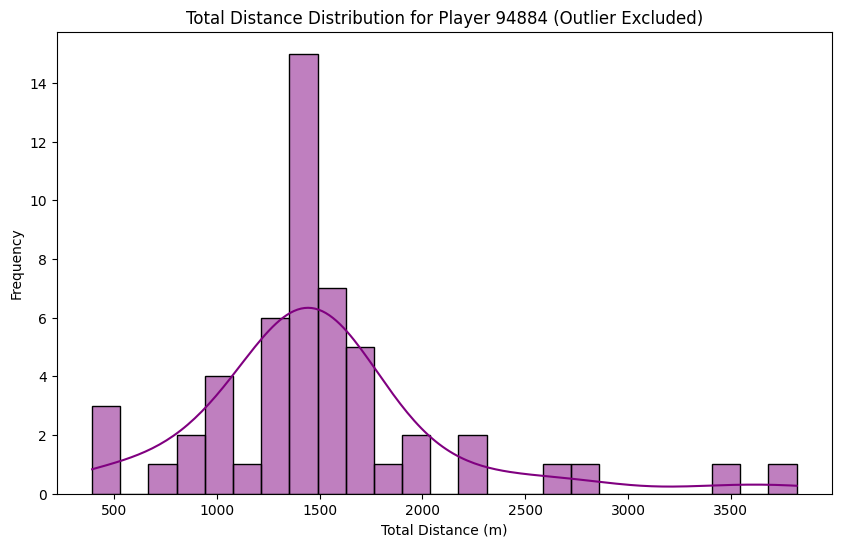

In [98]:
df_94884_filtered = df_94884[df_94884['total_distance'] <= 20000]

# Calculate mean, median, mode for the filtered data
mean_distance = df_94884_filtered['total_distance'].mean()
median_distance = df_94884_filtered['total_distance'].median()
mode_distance = df_94884_filtered['total_distance'].mode()[0] # .mode() can return multiple values, so take the first

print(f"Mean of total_distance (excluding outlier): {mean_distance:.2f} m")
print(f"Median of total_distance (excluding outlier): {median_distance:.2f} m")
print(f"Mode of total_distance (excluding outlier): {mode_distance:.2f} m")

# Plot histogram for the filtered data using Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df_94884_filtered['total_distance'], bins=25, kde=True, color='purple')
plt.title("Total Distance Distribution for Player 94884 (Outlier Excluded)")
plt.xlabel("Total Distance (m)")
plt.ylabel("Frequency")
plt.show()

Replace the anomalous value with the player's median match distance (computed above) and verify the fix.

In [99]:
df.loc[(df['player_id'] == 94884) & (df['total_distance'] >= 20000), 'total_distance'] = median_distance

# Verify the change
print("Value after replacement:")
print(df[(df['player_id'] == 94884) & (df['date'] == '2025-02-15')][['total_distance']])

Value after replacement:
      total_distance
3765     1461.144621


In [100]:
# Verify the bad row is actually fixed
print(df.loc[(df['player_id'] == 94884) & (df['date'] == '2025-02-15'), 
             ['total_distance', 'acc_band7plus_total_effort_count', 
              'velocity_band6plus7_total_distance']])

# Check: any remaining total_distance > 20000 anywhere?
print(f"Rows with total_distance > 20000: {(df['total_distance'] > 20000).sum()}")

      total_distance  acc_band7plus_total_effort_count  \
3765     1461.144621                                15   

      velocity_band6plus7_total_distance  
3765                           23.465222  
Rows with total_distance > 20000: 0


## 2.2 Suspect Player Profiles — Trialists and Placeholder Metadata

The 1969 birth year and `weight = 200` placeholder flag several players as likely trialists or academy call-ups whose metadata was not properly populated. We audit each before deciding to exclude or retain.

In [101]:
for pid in [42978, 86086, 93116, 15795, 60819, 89091]:
    rows = df[df['player_id'] == pid]
    print(f"Player {pid}: {len(rows)} rows, "
          f"{rows['date'].min().date()} to {rows['date'].max().date()}, "
          f"DOB: {rows['date_of_birth'].iloc[0].date()}")

Player 42978: 21 rows, 2024-07-27 to 2024-08-07, DOB: 1969-01-16
Player 86086: 10 rows, 2024-07-27 to 2024-08-01, DOB: 1969-12-05
Player 93116: 16 rows, 2024-07-29 to 2024-08-04, DOB: 2007-09-02
Player 15795: 30 rows, 2024-07-30 to 2025-06-26, DOB: 2005-06-02
Player 60819: 2 rows, 2025-06-18 to 2025-06-22, DOB: 2003-02-06
Player 89091: 3 rows, 2025-06-18 to 2025-06-26, DOB: 2004-01-10


In [102]:
# Drop preseason/end-of-season trialists and players with insufficient data
trialists_to_drop = [42978, 86086, 60819, 89091, 93116]
before = len(df)
df = df[~df['player_id'].isin(trialists_to_drop)].reset_index(drop=True)
print(f"Dropped {before - len(df)} rows across {len(trialists_to_drop)} players")

# Null the placeholder metadata for player 15795 (keep the rows, flag the metadata)
placeholder_mask = (df['player_id'] == 15795) & (df['height'] == 180) & (df['weight'] == 200)
assert placeholder_mask.sum() == 30, f"Expected 30 rows, got {placeholder_mask.sum()}"
df.loc[placeholder_mask, ['height', 'weight']] = np.nan

# Sanity check — no more 180/200 combinations anywhere
assert ((df['height'] == 180) & (df['weight'] == 200)).sum() == 0
print(f"Final dataset: {len(df)} rows, {df['player_id'].nunique()} players")

Dropped 52 rows across 5 players
Final dataset: 3832 rows, 29 players


In [103]:
df[['total_distance', 'acc_band7plus_total_effort_count', 
    'velocity_band6plus7_total_distance', 'height', 'weight', 'age']].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99, 0.999]
)

,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,age
count,3832.000000,3832.000000,3832.000000,3802.000000,3802.000000,3832.000000
mean,1328.175896,4.983820,13.405006,176.907154,73.226723,26.227296
std,918.056193,3.777794,20.774551,5.527150,6.583097,5.246595
min,44.093973,0.000000,0.000000,169.000000,64.000000,18.000000
1%,155.714654,0.000000,0.000000,169.000000,64.000000,18.000000
5%,306.374462,0.000000,0.000000,169.000000,64.000000,18.000000
50%,1170.961805,5.000000,1.284594,177.000000,71.000000,26.000000
95%,2861.971783,12.000000,56.338372,186.000000,84.000000,39.000000
99%,4828.080710,16.000000,89.930125,186.000000,85.000000,39.000000
99.9%,7516.966431,24.169000,136.256162,191.000000,85.000000,40.000000


# 3. Daily Aggregation

The raw data is at *period level* (one row per drill within a session). ACWR requires *daily* load totals. We aggregate to one row per `(player_id, date)`, preserving session composition via pivoted period counts and per-type load columns.

In [104]:
EXERCISE_TYPES = ['G', 'TAC', 'BP', 'TEC', 'MATCH']
LOAD_COLS = ['total_distance', 'acc_band7plus_total_effort_count', 'velocity_band6plus7_total_distance']

## 3.1 Aggregate to daily

For each player-day:
- **Load totals** (`total_distance`, `acc_total`, `hsr_total`) — summed across all periods.
- **Period counts** (`count_G`, `count_TAC`, etc.) — pivoted; preserved as session composition features for the model.
- **Per-type loads** (`td_G`, `acc_TAC`, etc.) — one pivot per metric × exercise type.
- **Static metadata** (position, height, weight, DOB) — `first` value (constant per player).

In [105]:
def aggregate_to_daily(df):
    """
    Aggregate row-level periods into player-day rows.
    Preserves exercise-type composition via pivoted count + per-type load columns.
    """
    # 1. Daily totals across all periods
    totals = df.groupby(['player_id', 'date'], observed=True).agg(
        total_distance=('total_distance', 'sum'),
        acc_total=('acc_band7plus_total_effort_count', 'sum'),
        hsr_total=('velocity_band6plus7_total_distance', 'sum'),
        is_match=('is_official_match', 'max'),
        n_periods=('activity_id', 'count'),
    ).reset_index()

    # 2. Count of periods per exercise type (pivot)
    counts = df.pivot_table(
        index=['player_id', 'date'],
        columns='exercise_type',
        values='activity_id',
        aggfunc='count',
        fill_value=0,
        observed=True,
    )
    # Ensure all 5 exercise-type columns exist even if absent in this slice
    counts = counts.reindex(columns=EXERCISE_TYPES, fill_value=0)
    counts = counts.add_prefix('count_').reset_index()

    # 3. Per-type load (one pivot per load metric)
    def pivot_load(values_col, prefix):
        out = df.pivot_table(
            index=['player_id', 'date'],
            columns='exercise_type',
            values=values_col,
            aggfunc='sum',
            fill_value=0,
            observed=True,
        )
        out = out.reindex(columns=EXERCISE_TYPES, fill_value=0)
        return out.add_prefix(f'{prefix}_').reset_index()

    td_per_type  = pivot_load('total_distance', 'td')
    acc_per_type = pivot_load('acc_band7plus_total_effort_count', 'acc')
    hsr_per_type = pivot_load('velocity_band6plus7_total_distance', 'hsr')

    # 4. Static per-player metadata (doesn't vary within a player)
    static = df.groupby('player_id', observed=True).agg(
        position_name_en=('position_name_en', 'first'),
        height=('height', 'first'),
        weight=('weight', 'first'),
        date_of_birth=('date_of_birth', 'first'),
    ).reset_index()

    # 5. Merge everything on player-day
    daily = (
        totals
        .merge(counts,       on=['player_id', 'date'], how='left')
        .merge(td_per_type,  on=['player_id', 'date'], how='left')
        .merge(acc_per_type, on=['player_id', 'date'], how='left')
        .merge(hsr_per_type, on=['player_id', 'date'], how='left')
        .merge(static,       on='player_id',           how='left')
    )

    # 6. Recompute age per row based on the actual date
    daily['age'] = (daily['date'] - daily['date_of_birth']).dt.days / 365.25

    # 7. Sanity checks
    assert len(daily) == df.groupby(['player_id', 'date']).ngroups, "Row count mismatch"
    assert daily[[f'count_{t}' for t in EXERCISE_TYPES]].sum().sum() == len(df), "Counts don't add up to row-level total"

    return daily.sort_values(['player_id', 'date']).reset_index(drop=True)


daily = aggregate_to_daily(df)
print(f"Shape: {daily.shape}")
print(f"Columns: {daily.columns.tolist()}")
daily.head()

Shape: (2119, 32)
Columns: ['player_id', 'date', 'total_distance', 'acc_total', 'hsr_total', 'is_match', 'n_periods', 'count_G', 'count_TAC', 'count_BP', 'count_TEC', 'count_MATCH', 'td_G', 'td_TAC', 'td_BP', 'td_TEC', 'td_MATCH', 'acc_G', 'acc_TAC', 'acc_BP', 'acc_TEC', 'acc_MATCH', 'hsr_G', 'hsr_TAC', 'hsr_BP', 'hsr_TEC', 'hsr_MATCH', 'position_name_en', 'height', 'weight', 'date_of_birth', 'age']


/var/folders/bl/dm6xfp0n2tndy27vk0xjd6jm0000gn/T/ipykernel_85422/260452707.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  assert len(daily) == df.groupby(['player_id', 'date']).ngroups, "Row count mismatch"


,player_id,date,total_distance,acc_total,hsr_total,is_match,n_periods,count_G,count_TAC,count_BP,...,hsr_G,hsr_TAC,hsr_BP,hsr_TEC,hsr_MATCH,position_name_en,height,weight,date_of_birth,age
0,11983,2024-07-29,3751.549912,22,81.922951,False,3,1,1,1,...,32.421798,49.501153,0.000000,0.0,0.000000,Central Midfielder,172.0,66.0,1985-11-07,38.724162
1,11983,2024-07-30,6059.586836,14,0.000000,False,3,1,1,1,...,0.000000,0.000000,0.000000,0.0,0.000000,Central Midfielder,172.0,66.0,1985-11-07,38.726899
2,11983,2024-08-01,5182.181222,9,59.335029,True,5,1,0,1,...,0.000000,0.000000,0.000000,0.0,59.335029,Central Midfielder,172.0,66.0,1985-11-07,38.732375
3,11983,2024-08-02,2842.762421,7,37.537185,False,3,1,1,1,...,33.801518,0.000000,3.735668,0.0,0.000000,Central Midfielder,172.0,66.0,1985-11-07,38.735113
4,11983,2024-08-03,1479.106082,3,20.534596,True,1,0,0,0,...,0.000000,0.000000,0.000000,0.0,20.534596,Central Midfielder,172.0,66.0,1985-11-07,38.737851


## 3.2 Full Calendar Grid

EWMA computation requires a **continuous daily series**. Gaps (rest days with no recorded activity) would distort the chronic load baseline and artificially inflate ACWR. We expand each player's timeline from their first observed session to the **global end date** (2025-06-26), filling missing days with zero load and flagging them with `is_rest = 1`.

In [106]:
def expand_to_full_grid(daily, end_date=None):
    """
    Expand each player's timeline to a continuous daily grid.
    - Start: player's first observed day
    - End: global maximum date (same for all players)
    - Missing days filled with zero load, is_rest=1.
    """
    if end_date is None:
        end_date = daily['date'].max()

    pieces = []
    for pid, g in daily.groupby('player_id', observed=True):
        start = g['date'].min()
        full_dates = pd.date_range(start=start, end=end_date, freq='D')
        full = pd.DataFrame({'player_id': pid, 'date': full_dates})
        merged = full.merge(g, on=['player_id', 'date'], how='left')
        pieces.append(merged)

    out = pd.concat(pieces, ignore_index=True)

    # Columns to fill with 0 on rest days
    load_cols = ['total_distance', 'acc_total', 'hsr_total', 'is_match', 'n_periods']
    count_cols = [f'count_{t}' for t in EXERCISE_TYPES]
    td_cols  = [f'td_{t}'  for t in EXERCISE_TYPES]
    acc_cols = [f'acc_{t}' for t in EXERCISE_TYPES]
    hsr_cols = [f'hsr_{t}' for t in EXERCISE_TYPES]
    zero_fill_cols = load_cols + count_cols + td_cols + acc_cols + hsr_cols
    out[zero_fill_cols] = out[zero_fill_cols].fillna(0)

    # Rest-day flag
    out['is_rest'] = (out['n_periods'] == 0).astype(int)

    # Forward-fill static metadata (constant per player, but NaN on rest days after merge)
    static_cols = ['position_name_en', 'height', 'weight', 'date_of_birth']
    out[static_cols] = out.groupby('player_id', observed=True)[static_cols].ffill().bfill()

    # Recompute age at each row's date
    out['age'] = (out['date'] - out['date_of_birth']).dt.days / 365.25

    return out.sort_values(['player_id', 'date']).reset_index(drop=True)


full_grid = expand_to_full_grid(daily)
print(f"Shape: {full_grid.shape}")
print(f"Rest days: {full_grid['is_rest'].sum()} / {len(full_grid)} "
      f"({full_grid['is_rest'].mean():.1%})")
print(f"Date range: {full_grid['date'].min().date()} → {full_grid['date'].max().date()}")
print(f"Players: {full_grid['player_id'].nunique()}")
full_grid.head()

Shape: (8872, 33)
Rest days: 6753 / 8872 (76.1%)
Date range: 2024-07-16 → 2025-06-26
Players: 29


,player_id,date,total_distance,acc_total,hsr_total,is_match,n_periods,count_G,count_TAC,count_BP,...,hsr_TAC,hsr_BP,hsr_TEC,hsr_MATCH,position_name_en,height,weight,date_of_birth,age,is_rest
0,11983,2024-07-29,3751.549912,22.0,81.922951,False,3.0,1.0,1.0,1.0,...,49.501153,0.000000,0.0,0.000000,Central Midfielder,172.0,66.0,1985-11-07,38.724162,0
1,11983,2024-07-30,6059.586836,14.0,0.000000,False,3.0,1.0,1.0,1.0,...,0.000000,0.000000,0.0,0.000000,Central Midfielder,172.0,66.0,1985-11-07,38.726899,0
2,11983,2024-07-31,0.000000,0.0,0.000000,0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,Central Midfielder,172.0,66.0,1985-11-07,38.729637,1
3,11983,2024-08-01,5182.181222,9.0,59.335029,True,5.0,1.0,0.0,1.0,...,0.000000,0.000000,0.0,59.335029,Central Midfielder,172.0,66.0,1985-11-07,38.732375,0
4,11983,2024-08-02,2842.762421,7.0,37.537185,False,3.0,1.0,1.0,1.0,...,0.000000,3.735668,0.0,0.000000,Central Midfielder,172.0,66.0,1985-11-07,38.735113,0


In [107]:
full_grid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8872 entries, 0 to 8871
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   player_id         8872 non-null   object        
 1   date              8872 non-null   datetime64[ns]
 2   total_distance    8872 non-null   float64       
 3   acc_total         8872 non-null   float64       
 4   hsr_total         8872 non-null   float64       
 5   is_match          8872 non-null   object        
 6   n_periods         8872 non-null   float64       
 7   count_G           8872 non-null   float64       
 8   count_TAC         8872 non-null   float64       
 9   count_BP          8872 non-null   float64       
 10  count_TEC         8872 non-null   float64       
 11  count_MATCH       8872 non-null   float64       
 12  td_G              8872 non-null   float64       
 13  td_TAC            8872 non-null   float64       
 14  td_BP             8872 n

## 3.3 Grid Diagnostics

Verify grid integrity and inspect session composition patterns across the squad.

In [108]:
# 1. One player's first 10 days — should show training days + rest days
pid = full_grid['player_id'].iloc[0]
full_grid[full_grid['player_id'] == pid].head(10)[
    ['date', 'total_distance', 'is_rest', 'count_G', 'count_TAC', 'count_BP', 'count_MATCH']
]

# 2. Active-day summary
active = full_grid[full_grid['is_rest'] == 0]
print(f"\nActive days: {len(active)}")
print(active[['total_distance', 'acc_total', 'hsr_total']].describe())

# 3. Exercise-type breakdown on active days only
print("\nAvg periods of each type on active days:")
print(active[[f'count_{t}' for t in EXERCISE_TYPES]].mean())


Active days: 2119
       total_distance    acc_total    hsr_total
count     2119.000000  2119.000000  2119.000000
mean      2401.873542     9.012742    24.241616
std       1654.866227     6.606956    27.917523
min         44.093973     0.000000     0.000000
25%       1310.301973     5.000000     0.000000
50%       1898.105081     7.000000    15.991967
75%       3162.846078    11.500000    36.533373
max      11552.250759    48.000000   244.337506

Avg periods of each type on active days:
count_G        0.547900
count_TAC      0.372345
count_BP       0.315243
count_TEC      0.122699
count_MATCH    0.450212
dtype: float64


### Exercise type frequency on active days

In [109]:
# How often does each type appear on an active day?
active = full_grid[full_grid['is_rest'] == 0]
for t in EXERCISE_TYPES:
    col = f'count_{t}'
    pct_days = (active[col] > 0).mean()
    avg_when_present = active.loc[active[col] > 0, col].mean()
    print(f"{t}: appears on {pct_days:.1%} of active days; "
          f"average count when present: {avg_when_present:.2f}")

G: appears on 46.0% of active days; average count when present: 1.19
TAC: appears on 32.6% of active days; average count when present: 1.14
BP: appears on 24.5% of active days; average count when present: 1.29
TEC: appears on 11.7% of active days; average count when present: 1.05
MATCH: appears on 44.0% of active days; average count when present: 1.02


### Common training day compositions (non-match days)

In [110]:
active_nonmatch = full_grid[(full_grid['is_rest'] == 0) & (full_grid['is_match'] == 0)]
combo = active_nonmatch[[f'count_{t}' for t in EXERCISE_TYPES if t != 'MATCH']].apply(
    lambda row: '+'.join([t.replace('count_', '') for t, v in row.items() if v > 0]) or 'none',
    axis=1
)
print(combo.value_counts().head(10))

G+TAC        338
G+BP         159
G+TAC+BP     150
G            118
TAC           93
G+BP+TEC      88
G+TEC         60
BP            51
G+TAC+TEC     47
TAC+BP        37
Name: count, dtype: int64


### Rest day analysis

Long consecutive rest streaks likely indicate injured players

In [111]:
rest = full_grid[full_grid['is_rest'] == 1]
print(f"Rest days: {len(rest)} ({len(rest)/len(full_grid):.1%} of grid)")

# Consecutive rest streaks per player — useful diagnostic
full_grid['rest_streak'] = (
    full_grid.groupby('player_id', observed=True)['is_rest']
    .transform(lambda s: s.groupby((s != s.shift()).cumsum()).cumcount() + 1) * full_grid['is_rest']
)
print(f"\nMax consecutive rest days per player:")
print(full_grid.groupby('player_id', observed=True)['rest_streak'].max().describe())

Rest days: 6753 (76.1% of grid)

Max consecutive rest days per player:
count     29.000000
mean      97.310345
std      110.983623
min        3.000000
25%       24.000000
50%       39.000000
75%      111.000000
max      329.000000
Name: rest_streak, dtype: float64


In [112]:
# Identify the extreme cases
streak_by_player = full_grid.groupby('player_id', observed=True).agg(
    max_streak=('rest_streak', 'max'),
    first_date=('date', 'min'),
    total_active_days=('is_rest', lambda s: (s == 0).sum()),
    total_days_in_grid=('date', 'count'),
).sort_values('max_streak', ascending=False)
streak_by_player['activity_rate'] = streak_by_player['total_active_days'] / streak_by_player['total_days_in_grid']
print(streak_by_player.head(10))

           max_streak first_date  total_active_days  total_days_in_grid  \
player_id                                                                 
82742             329 2024-07-27                  4                 335   
16464             326 2024-07-27                  6                 335   
53111             323 2024-07-27                  7                 335   
44207             323 2024-07-16                  9                 346   
88732             264 2024-08-08                 21                 323   
67157             229 2024-08-01                 34                 330   
55220             166 2024-07-27                 13                 335   
31083             111 2024-07-27                 98                 335   
15795              78 2024-07-30                 16                 332   
21206              64 2024-08-08                 76                 323   

           activity_rate  
player_id                 
82742           0.011940  
16464           0.

In [113]:
# Find "return events": days where is_rest=0 preceded by a long rest streak
full_grid_sorted = full_grid.sort_values(['player_id', 'date']).copy()

# Rest streak ending ON the previous row
full_grid_sorted['prev_streak'] = full_grid_sorted.groupby('player_id', observed=True)['rest_streak'].shift(1)

# A "return from long absence" is an active day (is_rest=0) where the previous streak was large
MIN_ABSENCE_DAYS = 28  # 4 weeks — typical injury absence threshold
returns = full_grid_sorted[
    (full_grid_sorted['is_rest'] == 0) & 
    (full_grid_sorted['prev_streak'] >= MIN_ABSENCE_DAYS)
]

print(f"Return-from-long-absence events (>= {MIN_ABSENCE_DAYS} days off):")
print(returns[['player_id', 'date', 'prev_streak']].to_string())
print(f"\nTotal: {len(returns)} events across {returns['player_id'].nunique()} players")

Return-from-long-absence events (>= 28 days off):
     player_id       date  prev_streak
391      15795 2024-09-26         52.0
477      15795 2024-12-21         74.0
509      15795 2025-01-22         31.0
611      15795 2025-05-04         78.0
664      15795 2025-06-26         38.0
1321     18236 2025-06-18         38.0
1725     21206 2024-09-26         45.0
2101     28635 2024-10-26         41.0
2659     30026 2025-06-18         30.0
2788     31083 2024-11-24        111.0
3257     37191 2025-03-27         29.0
4867     55220 2025-01-18        166.0
5298     59915 2024-10-07         35.0
5479     59915 2025-04-06         38.0
5556     59915 2025-06-22         28.0
5679     62110 2024-12-04         28.0
6141     64878 2025-04-22         40.0
7878     93025 2025-06-22         56.0

Total: 18 events across 12 players


### Player data sufficiency

Players with very few active days cannot reliably support a load prediction model. We flag players with fewer than 28 active days as **non-modelable**; these will need a position-based fallback strategy at inference time.

In [114]:
player_stats = full_grid.groupby('player_id', observed=True).agg(
    active_days=('is_rest', lambda s: (s == 0).sum()),
    grid_days=('date', 'count'),
    max_streak=('rest_streak', 'max'),
).reset_index()
player_stats['activity_rate'] = player_stats['active_days'] / player_stats['grid_days']

# A player is "modelable" if they have enough data to learn from
# Threshold is a judgment call — defend it
MIN_ACTIVE_DAYS = 28
player_stats['is_modelable'] = player_stats['active_days'] >= MIN_ACTIVE_DAYS

full_grid = full_grid.merge(
    player_stats[['player_id', 'activity_rate', 'is_modelable']],
    on='player_id', how='left'
)

print(f"Modelable players: {player_stats['is_modelable'].sum()} / {len(player_stats)}")
print(player_stats.sort_values('active_days'))

Modelable players: 20 / 29
    player_id  active_days  grid_days  max_streak  activity_rate  is_modelable
11      43211            3          9           3       0.333333         False
23      84160            3          9           3       0.333333         False
22      82742            4        335         329       0.011940         False
2       16464            6        335         326       0.017910         False
14      53111            7        335         323       0.020896         False
12      44207            9        346         323       0.026012         False
15      55220           13        335         166       0.038806         False
1       15795           16        332          78       0.048193         False
24      88732           21        323         264       0.065015         False
20      67157           34        330         229       0.103030          True
16      59105           46        188          62       0.244681          True
19      64878           7

# 4. EWMA-Based ACWR Computation

The Acute:Chronic Workload Ratio compares a player's recent load (acute, ~7 days) to their longer-term baseline (chronic, ~28 days). Values in **0.8–1.3** are generally considered safe; values above **1.5** signal elevated injury risk.

We use the **EWMA formulation** (Williams et al., 2017) — it weights recent sessions more heavily and handles rest-day decay more realistically than simple rolling averages:

```
acute[t]   = λ_a · load[t] + (1 − λ_a) · acute[t-1]     λ_a = 2/(7+1)  = 0.25
chronic[t] = λ_c · load[t] + (1 − λ_c) · chronic[t-1]   λ_c = 2/(28+1) ≈ 0.069
ACWR[t]    = acute[t] / chronic[t]
```

ACWR is computed **independently** for all three load metrics.

## 4.1 EWMA decay — understanding the smoothing parameter

With `λ_acute = 0.25`, the most recent 7 days account for ~87% of the acute load signal. Older sessions decay exponentially — a session 14 days ago contributes less than 2%.

In [115]:
lam = 0.25
weights = lam * (1 - lam) ** np.arange(20)
print(weights)
print(f"Sum of first 7: {weights[:7].sum():.3f}")  # should be close to 1
print(f"Sum of all: {weights.sum():.3f}")           # converges to 1 as t → ∞

[0.25       0.1875     0.140625   0.10546875 0.07910156 0.05932617
 0.04449463 0.03337097 0.02502823 0.01877117 0.01407838 0.01055878
 0.00791909 0.00593932 0.00445449 0.00334087 0.00250565 0.00187924
 0.00140943 0.00105707]
Sum of first 7: 0.867
Sum of all: 0.997


## 4.2 EWMA helper function

Initialised from zero (`EWMA[−1] = 0`) per Williams et al. (2017). A zero is prepended before calling pandas `ewm` so the recursion starts from the correct initial state, then the artificial leading value is dropped.

In [116]:
def ewma(values, lam):
    """
    Exponentially weighted moving average with EWMA[-1] = 0 initialization
    (Williams et al. 2017 formulation).
    
    EWMA[t] = values[t] * lam + EWMA[t-1] * (1 - lam)
    
    Parameters
    ----------
    values : 1D array-like of daily loads
    lam : float, smoothing parameter (e.g., 0.25 for 7-day acute)
    
    Returns
    -------
    np.ndarray of same length as values
    """
    # Prepend a zero so pandas' ewm starts from EWMA[-1] = 0,
    # then drop the prepended result
    s = pd.Series(np.concatenate([[0.0], np.asarray(values, dtype=float)]))
    result = s.ewm(alpha=lam, adjust=False).mean().values
    return result[1:]  # drop the artificial initial zero

## 4.3 Per-player ACWR computation

For each player's timeline:
- **Warmup masking**: first 28 days set to `NaN` — chronic EWMA needs ~28 days to converge from zero initialisation.
- **Division-by-zero**: `NaN` wherever `chronic == 0` (player has never trained; ratio is undefined).

In [117]:
def compute_acwr_for_player(daily_loads, warmup_days=28):
    """
    Compute EWMA-based acute load, chronic load, and ACWR for a single player,
    single load metric.

    Parameters
    ----------
    daily_loads : pd.Series
        Daily load values indexed by date. No gaps (rest days must be 0).
    warmup_days : int
        Number of initial days to mask as NaN (default 28).

    Returns
    -------
    pd.DataFrame with same index as daily_loads and columns:
        acute, chronic, acwr, is_warmup
    """
    # Smoothing parameters: lambda = 2 / (N + 1)
    lam_acute = 2 / (7 + 1)      # 0.25
    lam_chronic = 2 / (28 + 1)   # ~0.0690

    # Compute the two EWMA series using the ewma() function you already have
    acute = ewma(daily_loads.values, lam_acute)
    chronic = ewma(daily_loads.values, lam_chronic)

    # Safe division: NaN wherever chronic is 0 (undefined ratio)
    with np.errstate(divide='ignore', invalid='ignore'):
        acwr = np.where(chronic > 0, acute / chronic, np.nan)

    # Mask the warmup period — chronic EWMA hasn't stabilized yet
    is_warmup = np.arange(len(daily_loads)) < warmup_days
    acwr = np.where(is_warmup, np.nan, acwr)

    # Shape sanity check
    assert len(acute) == len(chronic) == len(acwr) == len(daily_loads)

    return pd.DataFrame({
        'acute': acute,
        'chronic': chronic,
        'acwr': acwr,
        'is_warmup': is_warmup,
    }, index=daily_loads.index)

## 4.4 Apply ACWR to the full grid

Iterates over all 29 players × 3 metrics, attaching `{metric}_acute`, `{metric}_chronic`, and `{metric}_acwr` columns to the grid. `is_warmup` is captured once (identical window for all metrics).

In [118]:
def add_acwr_to_grid(full_grid, metrics=None, warmup_days=28):
    """
    Compute EWMA-ACWR for every player × every load metric and attach to the grid.
    
    Parameters
    ----------
    full_grid : pd.DataFrame
        Must have columns: player_id, date, and the load metric columns.
        Must be a complete daily grid (rest days zero-filled).
    metrics : list of str, optional
        Load metric column names to process. Defaults to the three we use.
    warmup_days : int
        Passed to compute_acwr_for_player.
    
    Returns
    -------
    pd.DataFrame: full_grid with added columns per metric:
        {metric}_acute, {metric}_chronic, {metric}_acwr
        plus a single is_warmup column (same for all metrics).
    """
    if metrics is None:
        metrics = ['total_distance', 'acc_total', 'hsr_total']
    
    # Sort by (player, date) so the EWMA recursion runs in chronological order
    out = full_grid.sort_values(['player_id', 'date']).reset_index(drop=True).copy()
    
    # We'll capture is_warmup once (it's identical across metrics — same warmup window)
    warmup_captured = False
    warmup_arrays = []
    
    for metric in metrics:
        acute_arrays = []
        chronic_arrays = []
        acwr_arrays = []
        
        for pid, g in out.groupby('player_id', observed=True, sort=False):
            series = g.set_index('date')[metric]
            res = compute_acwr_for_player(series, warmup_days=warmup_days)
            
            acute_arrays.append(res['acute'].values)
            chronic_arrays.append(res['chronic'].values)
            acwr_arrays.append(res['acwr'].values)
            
            if not warmup_captured:
                warmup_arrays.append(res['is_warmup'].values)
        
        out[f'{metric}_acute'] = np.concatenate(acute_arrays)
        out[f'{metric}_chronic'] = np.concatenate(chronic_arrays)
        out[f'{metric}_acwr'] = np.concatenate(acwr_arrays)
        
        warmup_captured = True  # only capture once
    
    out['is_warmup'] = np.concatenate(warmup_arrays)
    
    return out


full_grid = add_acwr_to_grid(full_grid)

# Sanity check
print(f"Shape: {full_grid.shape}")
print(f"New columns:", [c for c in full_grid.columns if 'acute' in c or 'chronic' in c or 'acwr' in c or 'warmup' in c])
print(f"\nACWR summary on ACTIVE days (post-warmup):")
active_post_warmup = full_grid[(full_grid['is_rest'] == 0) & (~full_grid['is_warmup'])]
for m in ['total_distance', 'acc_total', 'hsr_total']:
    s = active_post_warmup[f'{m}_acwr']
    print(f"  {m}_acwr: median={s.median():.3f}, p25={s.quantile(0.25):.3f}, "
          f"p75={s.quantile(0.75):.3f}, p95={s.quantile(0.95):.3f}")

Shape: (8872, 46)
New columns: ['total_distance_acute', 'total_distance_chronic', 'total_distance_acwr', 'acc_total_acute', 'acc_total_chronic', 'acc_total_acwr', 'hsr_total_acute', 'hsr_total_chronic', 'hsr_total_acwr', 'is_warmup']

ACWR summary on ACTIVE days (post-warmup):
  total_distance_acwr: median=1.300, p25=1.076, p75=1.582, p95=2.185
  acc_total_acwr: median=1.316, p25=1.072, p75=1.585, p95=2.169
  hsr_total_acwr: median=1.200, p25=0.822, p75=1.575, p95=2.270


## 4.5 Trajectory visualisation

ACWR trajectories for the most active modelable player (post-warmup). Green band = safe zone (0.8–1.3); dashed red line = elevated-risk threshold (1.5).

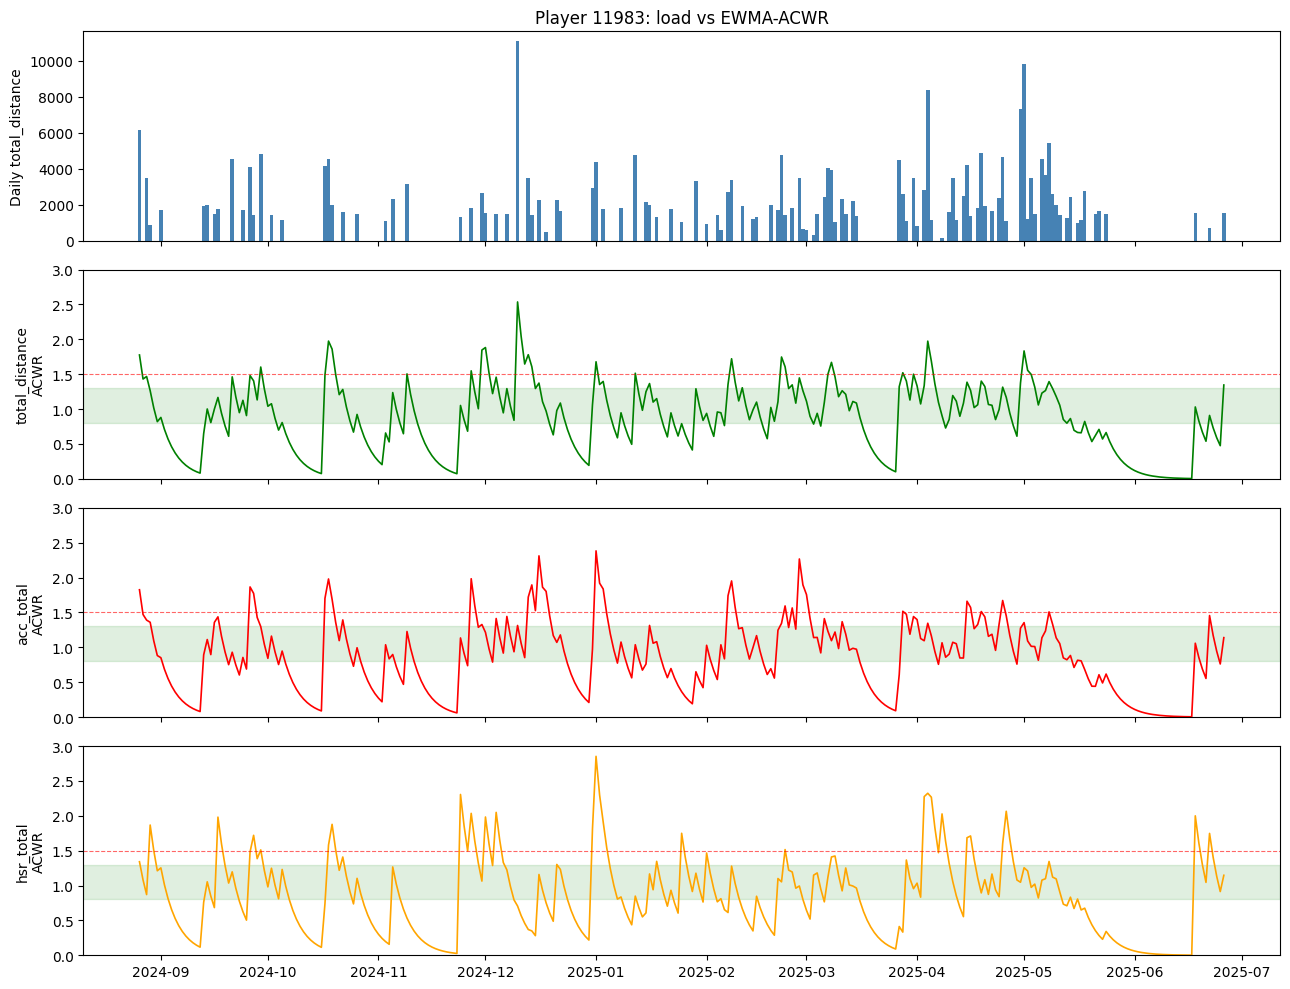

In [119]:
pid = full_grid[full_grid['is_modelable']].groupby('player_id', observed=True)['is_rest'].apply(
    lambda s: (s==0).mean()
).idxmax()

p = full_grid[(full_grid['player_id'] == pid) & (~full_grid['is_warmup'])].copy()

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].bar(p['date'], p['total_distance'], color='steelblue', width=1.0)
axes[0].set_ylabel('Daily total_distance')
axes[0].set_title(f'Player {pid}: load vs EWMA-ACWR')

for ax, metric, color in zip(axes[1:], 
                              ['total_distance', 'acc_total', 'hsr_total'],
                              ['green', 'red', 'orange']):
    ax.plot(p['date'], p[f'{metric}_acwr'], color=color, lw=1.2)
    ax.axhspan(0.8, 1.3, alpha=0.12, color='green')
    ax.axhline(1.5, color='red', ls='--', lw=0.8, alpha=0.6)
    ax.set_ylabel(f'{metric}\nACWR')
    ax.set_ylim(0, 3)

plt.tight_layout()
plt.show()